# Shot Quality Auditor — La Liga 2015/16
**Project 1 | StatsBomb Open Data**

Thesis: xG is only one part of the picture when evaluating a player or team.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from mplsoccer import Pitch
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('data/la_liga_1516_events.parquet')

print(f'Shape: {df.shape}')
print(f'\nColumns ({len(df.columns)} total):')
for col in sorted(df.columns):
    print(f'  {col}')

Shape: (1295354, 117)

Columns (117 total):
  50_50
  bad_behaviour_card
  ball_receipt_outcome
  ball_recovery_offensive
  ball_recovery_recovery_failure
  block_deflection
  block_offensive
  block_save_block
  carry_end_location
  clearance_aerial_won
  clearance_body_part
  clearance_head
  clearance_left_foot
  clearance_other
  clearance_right_foot
  counterpress
  dribble_no_touch
  dribble_nutmeg
  dribble_outcome
  dribble_overrun
  duel_outcome
  duel_type
  duration
  foul_committed_advantage
  foul_committed_card
  foul_committed_offensive
  foul_committed_penalty
  foul_committed_type
  foul_won_advantage
  foul_won_defensive
  foul_won_penalty
  goalkeeper_body_part
  goalkeeper_end_location
  goalkeeper_lost_in_play
  goalkeeper_lost_out
  goalkeeper_outcome
  goalkeeper_position
  goalkeeper_punched_out
  goalkeeper_shot_saved_off_target
  goalkeeper_shot_saved_to_post
  goalkeeper_success_in_play
  goalkeeper_success_out
  goalkeeper_technique
  goalkeeper_type
  half_

In [15]:
REQUIRED_FIELDS = [
    'location',
    'team',
    'player',
    'shot_statsbomb_xg',
    'shot_outcome',
    'shot_body_part',
    'shot_type',
    'type',
    'match_id',
]

missing = [f for f in REQUIRED_FIELDS if f not in df.columns]
if missing:
    raise ValueError(
        f'The following required fields are missing from the parquet: {missing}\n'
        f'Re-run the data loading pipeline to regenerate the parquet.'
    )

print('All required fields present.')

shots_check = df[df['type'] == 'Shot']
print(f'\nshot_outcome unique values:')
print(shots_check['shot_outcome'].unique())

All required fields present.

shot_outcome unique values:
<ArrowStringArray>
[           'Off T',            'Saved',          'Blocked',
             'Goal',             'Post',          'Wayward',
 'Saved Off Target',    'Saved to Post']
Length: 8, dtype: str


In [11]:
TEAMS_IN_SCOPE = ['Barcelona', 'Real Madrid', 'Atlético Madrid', 'Levante UD']
PLAYERS_IN_SCOPE = ['Luis Alberto Suárez Díaz', 'Cristiano Ronaldo dos Santos Aveiro']

all_shots = df[df['type'] == 'Shot'].copy()
print(f'All shots in dataset:        {len(all_shots):>6}')

team_shots = all_shots[all_shots['team'].isin(TEAMS_IN_SCOPE)].copy()
print(f'Shots by scoped teams:       {len(team_shots):>6}')
print(f'  Teams found: {team_shots["team"].unique()}')

player_shots = all_shots[all_shots['player'].isin(PLAYERS_IN_SCOPE)].copy()
print(f'\nShots by scoped players:     {len(player_shots):>6}')
print(f'  Players found: {player_shots["player"].unique()}')

for p in PLAYERS_IN_SCOPE:
    n = len(player_shots[player_shots['player'] == p])
    if n == 0:
        raise ValueError(
            f'{p} not found in shot events. '
            f'Check name spelling against: {all_shots["player"].unique()}'
        )
    print(f'  {p}: {n} shots')

All shots in dataset:          9168
Shots by scoped teams:         2247
  Teams found: <ArrowStringArray>
['Levante UD', 'Real Madrid', 'Atlético Madrid', 'Barcelona']
Length: 4, dtype: str

Shots by scoped players:        367
  Players found: <ArrowStringArray>
['Cristiano Ronaldo dos Santos Aveiro', 'Luis Alberto Suárez Díaz']
Length: 2, dtype: str
  Luis Alberto Suárez Díaz: 139 shots
  Cristiano Ronaldo dos Santos Aveiro: 228 shots


In [16]:
# Minutes played — sourced from Transfermarkt, La Liga 2015/16.
# Goals per 90 formula: (total_goals / total_minutes_played) * 90
# Only players above the 500-minute threshold are assigned a Goals per 90 value.
PLAYER_MINUTES = {
    'Cristiano Ronaldo dos Santos Aveiro': 3184,
    'Luis Alberto Suárez Díaz': 3150,
}

def compute_player_metrics(shots_df, minutes_lookup, min_minutes=500):
    """
    Compute shot and goal metrics per player.
    Goals per 90 is only assigned when total minutes exceed min_minutes.
    minutes_lookup: dict of {player_name -> total_minutes_played}
    """
    records = []
    for name, group in shots_df.groupby('player'):
        total_shots = len(group)
        total_xg = group['shot_statsbomb_xg'].sum()

        goals = group[group['shot_outcome'] == 'Goal']
        total_goals = len(goals)
        fk_goals = len(goals[goals['shot_type'] == 'Free Kick'])
        pen_goals = len(goals[goals['shot_type'] == 'Penalty'])
        head_goals = len(goals[goals['shot_body_part'] == 'Head'])

        total_minutes = minutes_lookup.get(name)
        if total_minutes is not None and total_minutes > min_minutes:
            goals_per_90 = round((total_goals / total_minutes) * 90, 2)
        else:
            goals_per_90 = np.nan

        records.append({
            'player': name,
            'Total Shots': total_shots,
            'Total xG': round(total_xg, 2),
            'Total Goals': total_goals,
            'Goals per 90': goals_per_90,
            'Free Kick Goals': fk_goals,
            'Penalty Goals': pen_goals,
            'Header Goals': head_goals,
        })

    return pd.DataFrame(records)


def compute_team_metrics(shots_df):
    """
    Compute shot and goal metrics per team.
    Exclude Goals per 90.
    """
    records = []
    for name, group in shots_df.groupby('team'):
        total_shots = len(group)
        total_xg = group['shot_statsbomb_xg'].sum()

        goals = group[group['shot_outcome'] == 'Goal']
        total_goals = len(goals)
        fk_goals = len(goals[goals['shot_type'] == 'Free Kick'])
        pen_goals = len(goals[goals['shot_type'] == 'Penalty'])
        head_goals = len(goals[goals['shot_body_part'] == 'Head'])

        records.append({
            'team': name,
            'Total Shots': total_shots,
            'Total xG': round(total_xg, 2),
            'Total Goals': total_goals,
            'Free Kick Goals': fk_goals,
            'Penalty Goals': pen_goals,
            'Header Goals': head_goals,
        })

    return pd.DataFrame(records)


player_summary = compute_player_metrics(player_shots, PLAYER_MINUTES)
team_summary = compute_team_metrics(team_shots)

print('PLAYER SUMMARY TABLE')
display(player_summary)

print('\nTEAM SUMMARY TABLE')
display(team_summary)

PLAYER SUMMARY TABLE


,player,Total Shots,Total xG,Total Goals,Goals per 90,Free Kick Goals,Penalty Goals,Header Goals
0,Cristiano Ronaldo dos Santos Aveiro,228,31.97,35,0.99,1,6,6
1,Luis Alberto Suárez Díaz,139,27.65,40,1.14,0,3,5



TEAM SUMMARY TABLE


,team,Total Shots,Total xG,Total Goals,Free Kick Goals,Penalty Goals,Header Goals
0,Atlético Madrid,483,52.97,62,2,1,9
1,Barcelona,604,91.43,109,5,11,9
2,Levante UD,443,36.72,36,3,2,7
3,Real Madrid,717,80.79,108,3,6,24


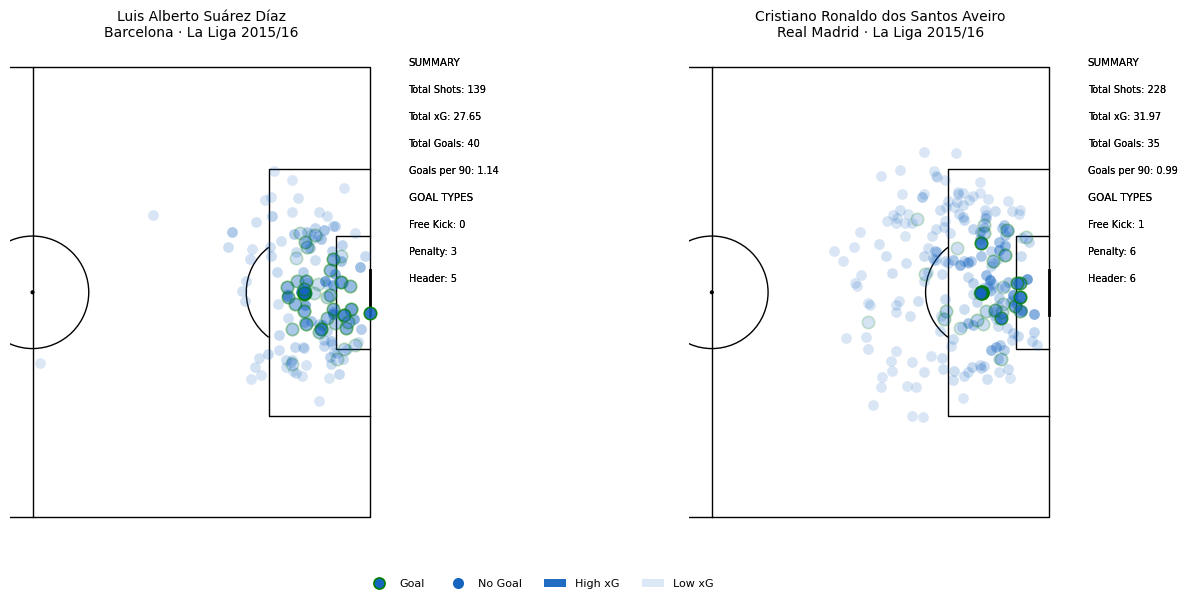

Saved: outputs/striker_shot_maps.png


In [18]:
# Striker shot maps
# 2-column grid: Suárez (left), Ronaldo (right).
# Half-pitch view. Dot opacity encodes xG. Outlined dots = goals.

PITCH_COLOR = 'white'
LINE_COLOR = 'black'
DOT_COLOR = '#1565C0'
DOT_LOW_ALPHA = 0.15
DOT_HIGH_ALPHA = 0.95


def xg_to_alpha(xg_series):
    """Linearly map xG values (0–1) to alpha range [DOT_LOW_ALPHA, DOT_HIGH_ALPHA]."""
    xg = xg_series.clip(0, 1)
    return DOT_LOW_ALPHA + (DOT_HIGH_ALPHA - DOT_LOW_ALPHA) * xg


def draw_striker_map(ax, shots, player_name):
    """
    Draw a single striker shot map on the given axes.
    Half-pitch. Goals outlined in black. Dot opacity encodes xG.
    """
    pitch = Pitch(
        pitch_type='statsbomb',
        pitch_color=PITCH_COLOR,
        line_color=LINE_COLOR,
        linewidth=1,
        half=True,
    )
    pitch.draw(ax=ax)
    ax.axis('off')

    goals = shots[shots['shot_outcome'] == 'Goal']
    non_goals = shots[shots['shot_outcome'] != 'Goal']

    def get_xy(df_subset):
        locs = df_subset['location'].dropna()
        x = locs.apply(lambda l: l[0])
        y = locs.apply(lambda l: l[1])
        xg = df_subset.loc[locs.index, 'shot_statsbomb_xg']
        return x, y, xg

    x_ng, y_ng, xg_ng = get_xy(non_goals)
    alphas_ng = xg_to_alpha(xg_ng)
    for xi, yi, ai in zip(x_ng, y_ng, alphas_ng):
        ax.scatter(xi, yi, s=60, color=DOT_COLOR, alpha=ai, linewidths=0, zorder=3)

    x_g, y_g, xg_g = get_xy(goals)
    alphas_g = xg_to_alpha(xg_g)
    for xi, yi, ai in zip(x_g, y_g, alphas_g):
        ax.scatter(xi, yi, s=80, color=DOT_COLOR, alpha=ai,
                   linewidths=1.2, edgecolors='green', zorder=4)

    team = shots['team'].iloc[0] if len(shots) > 0 else ''
    ax.set_title(
        f'{player_name}\n{team} · La Liga 2015/16',
        fontsize=10, fontweight='normal', color='black', pad=6
    )


def add_stats_text(fig, ax, summary_row):
    """
    Add a text annotation block to the left or right of the pitch axes.
    """
    bbox = ax.get_position()

    x_pos = bbox.x1 + 0.01
    lines = [
            ('SUMMARY', None),
            ('Total Shots', int(summary_row['Total Shots'])),
            ('Total xG', f"{summary_row['Total xG']:.2f}"),
            ('Total Goals', int(summary_row['Total Goals'])),
            ('Goals per 90', f"{summary_row['Goals per 90']:.2f}"),
            ('GOAL TYPES', None),
            ('Free Kick', int(summary_row['Free Kick Goals'])),
            ('Penalty', int(summary_row['Penalty Goals'])),
            ('Header', int(summary_row['Header Goals'])),
        ]

    y_start = bbox.y1 - 0.02
    y_step = 0.045

    for i, (label, value) in enumerate(lines):
        y = y_start - i * y_step
        if value is None:
            fig.text(x_pos, y, label, fontsize=7.5, fontweight='normal',
                     color='black', va='top', transform=fig.transFigure)
        else:
            fig.text(x_pos, y, f'{label}: {value}', fontsize=7, color='black',
                    va='top', transform=fig.transFigure)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

for ax, player_name in zip(axes, PLAYERS_IN_SCOPE):
    shots = player_shots[player_shots['player'] == player_name]
    draw_striker_map(ax, shots, player_name)

plt.tight_layout(pad=2.5)

for ax, player_name in zip(axes, PLAYERS_IN_SCOPE):
    summary_row = player_summary[player_summary['player'] == player_name].iloc[0]
    add_stats_text(fig, ax, summary_row)
    add_stats_text(fig, ax, summary_row)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=DOT_COLOR,
           markeredgecolor='green', markeredgewidth=1.2, markersize=8, label='Goal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=DOT_COLOR,
           markeredgecolor='none', markersize=8, label='No Goal'),
    mpatches.Patch(facecolor=DOT_COLOR, alpha=DOT_HIGH_ALPHA, label='High xG'),
    mpatches.Patch(facecolor=DOT_COLOR, alpha=DOT_LOW_ALPHA, label='Low xG'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=4,
    fontsize=8,
    frameon=False,
    bbox_to_anchor=(0.5, -0.04)
)

plt.savefig('outputs/striker_shot_maps.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Saved: outputs/striker_shot_maps.png')

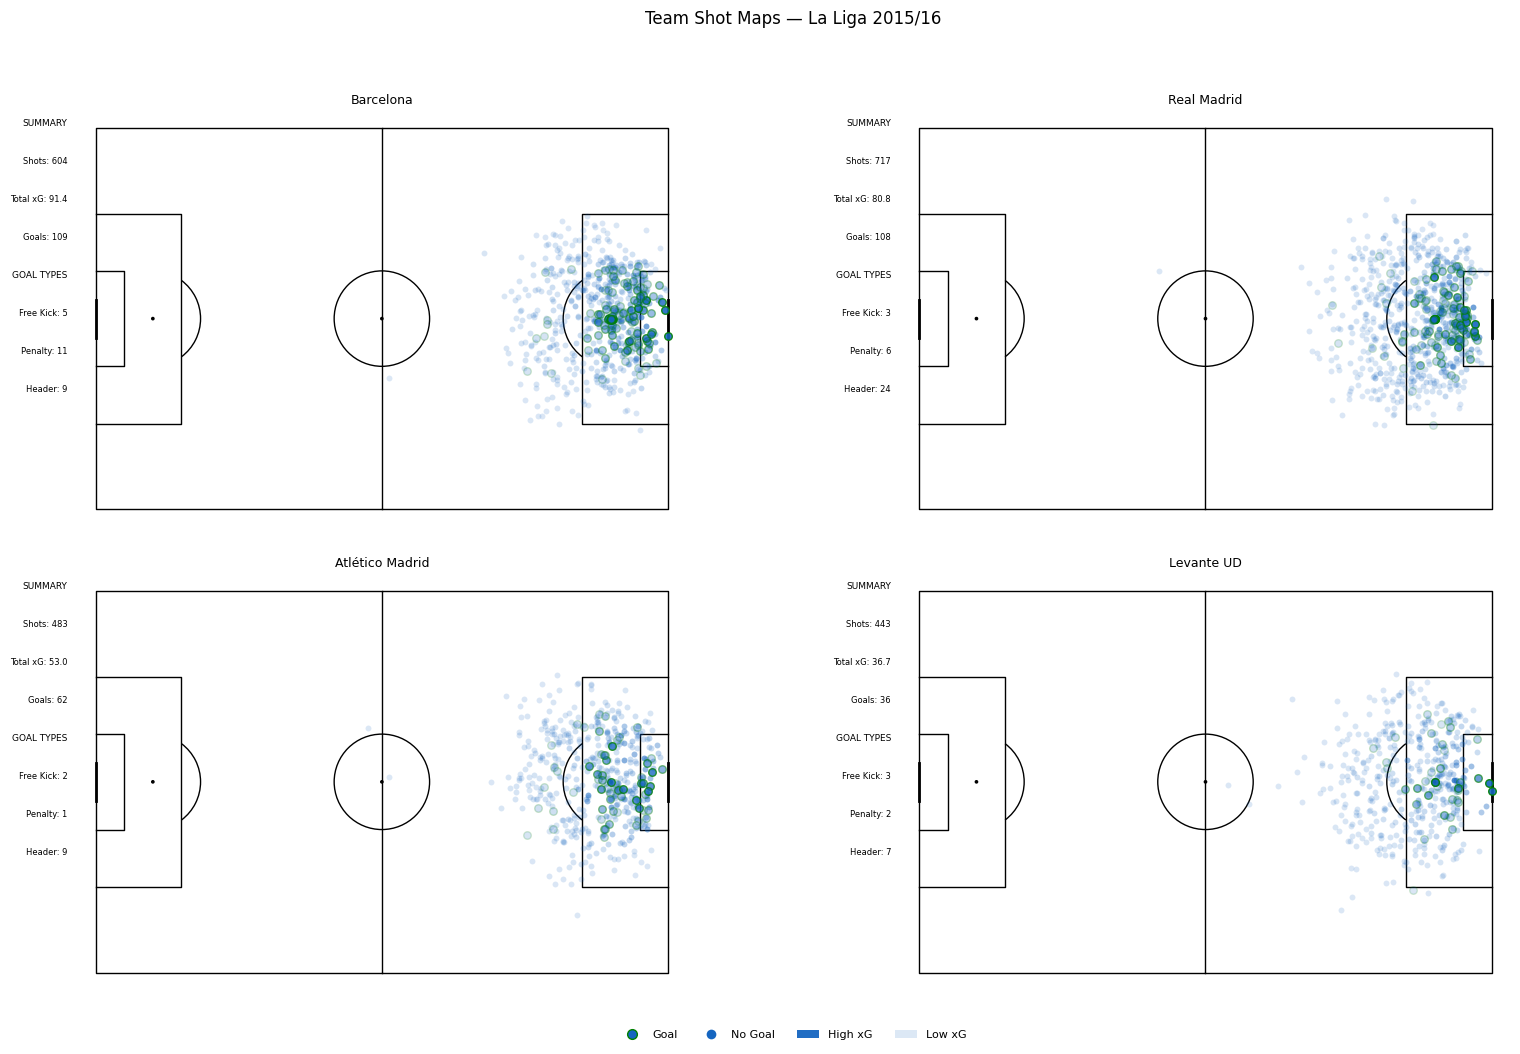

Saved: outputs/team_shot_maps.png


In [20]:
# Team shot maps
# 2x2 grid: Barcelona (top-left), Real Madrid (top-right),
#            Atlético Madrid (bottom-left), Levante UD (bottom-right).
# Full pitch. Dot opacity encodes xG. Outlined dots = goals.

TEAM_ORDER = ['Barcelona', 'Real Madrid', 'Atlético Madrid', 'Levante UD']


def draw_team_map(ax, shots, team_name):
    """Draw a single team shot map on the given axes (full pitch)."""
    pitch = Pitch(
        pitch_type='statsbomb',
        pitch_color=PITCH_COLOR,
        line_color=LINE_COLOR,
        linewidth=1,
        half=False,
    )
    pitch.draw(ax=ax)
    ax.axis('off')

    goals = shots[shots['shot_outcome'] == 'Goal']
    non_goals = shots[shots['shot_outcome'] != 'Goal']

    def get_xy(df_subset):
        locs = df_subset['location'].dropna()
        x = locs.apply(lambda l: l[0])
        y = locs.apply(lambda l: l[1])
        xg = df_subset.loc[locs.index, 'shot_statsbomb_xg']
        return x, y, xg

    x_ng, y_ng, xg_ng = get_xy(non_goals)
    alphas_ng = xg_to_alpha(xg_ng)
    for xi, yi, ai in zip(x_ng, y_ng, alphas_ng):
        ax.scatter(xi, yi, s=18, color=DOT_COLOR, alpha=ai, linewidths=0, zorder=3)

    x_g, y_g, xg_g = get_xy(goals)
    alphas_g = xg_to_alpha(xg_g)
    for xi, yi, ai in zip(x_g, y_g, alphas_g):
        ax.scatter(xi, yi, s=30, color=DOT_COLOR, alpha=ai,
                   linewidths=1.0, edgecolors='green', zorder=4)

    ax.set_title(team_name, fontsize=9, fontweight='normal', color='black', pad=4)


fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.patch.set_facecolor('white')
fig.suptitle('Team Shot Maps — La Liga 2015/16', fontsize=12,
             fontweight='normal', color='black', y=1.01)

axes_flat = axes.flatten()

for ax, team_name in zip(axes_flat, TEAM_ORDER):
    shots = team_shots[team_shots['team'] == team_name]
    draw_team_map(ax, shots, team_name)

plt.tight_layout(pad=2.0)

for ax, team_name in zip(axes_flat, TEAM_ORDER):
    summary_row = team_summary[team_summary['team'] == team_name].iloc[0]
    bbox = ax.get_position()

    stats_lines = [
        ('SUMMARY', None),
        ('Shots', int(summary_row['Total Shots'])),
        ('Total xG', f"{summary_row['Total xG']:.1f}"),
        ('Goals', int(summary_row['Total Goals'])),
        ('GOAL TYPES', None),
        ('Free Kick', int(summary_row['Free Kick Goals'])),
        ('Penalty', int(summary_row['Penalty Goals'])),
        ('Header', int(summary_row['Header Goals'])),
    ]

    y_start = bbox.y1 - 0.01
    y_step = 0.038

    for i, (label, value) in enumerate(stats_lines):
        y = y_start - i * y_step
        if value is None:
            fig.text(bbox.x0 - 0.005, y, label, fontsize=6.5, fontweight='normal',
                     color='black', ha='right', va='top')
        else:
            fig.text(bbox.x0 - 0.005, y, f'{label}: {value}', fontsize=6,
                     color='black', ha='right', va='top')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=DOT_COLOR,
           markeredgecolor='green', markeredgewidth=1.0, markersize=7, label='Goal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=DOT_COLOR,
           markeredgecolor='none', markersize=7, label='No Goal'),
    mpatches.Patch(facecolor=DOT_COLOR, alpha=DOT_HIGH_ALPHA, label='High xG'),
    mpatches.Patch(facecolor=DOT_COLOR, alpha=DOT_LOW_ALPHA, label='Low xG'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=4,
    fontsize=8,
    frameon=False,
    bbox_to_anchor=(0.5, -0.03)
)

plt.savefig('outputs/team_shot_maps.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Saved: outputs/team_shot_maps.png')